### Predicting Kidney function using PyTorch Frame

<p>
PyTorch Frame is a deep learning library made using PyTorch that is designed to perform for tabular data.
</p>

#### Requirements

In [1]:
%pip install torchview -qq
%pip install mplcyberpunk -qq
%pip install cmasher -qq
%pip install pytorch-frame -qq

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 8.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.3/146.3 kB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


<p>
PyTorch Frame is a deep learning library made using PyTorch that is designed to perform for tabular data.
</p>

#### Imports

In [2]:
import kagglehub
import os
import torchinfo
import torchview
import mplcyberpunk
import cmasher
import warnings
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import polars.selectors as cs

from typing import Any
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import gaussian_kde

import torch
import torch_frame
from torch_frame import stype
from torch_frame.nn.conv import TabTransformerConv
from torch_frame.nn.encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeWiseFeatureEncoder,
)
from torch_frame.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.style.use('cyberpunk')

#### Loading the dataset and simple EDA with plots

In [3]:
df = pl.read_csv('/kaggle/input/kidney-function-health-dataset/kidney_dataset.csv')

In [4]:
mapping = {"ARB" : "ARB", "Diuretic" : "Diuretic", "None" : "No medication", "ACE Inhibitor" : "ACE Inhibitor"}

df = df.with_columns(
    pl.col('Medication').replace_strict(mapping)
)

In [5]:
df.head()

Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
f64,f64,f64,f64,i64,i64,f64,f64,f64,str,i64
0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.57037,"""No medication""",0
3.41397,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,"""ACE Inhibitor""",1
0.647645,7.46654,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,"""Diuretic""",0
0.795508,12.516821,99.87218,2360.60298,0,0,32.3919,116.09887,3.086846,"""ACE Inhibitor""",0
0.86901,19.85596,86.110182,1987.750901,0,1,66.689515,55.66876,2.17498,"""ARB""",0


In [6]:
df.tail()

Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
f64,f64,f64,f64,i64,i64,f64,f64,f64,str,i64
4.048737,53.09402,24.964596,1179.120228,1,1,64.910042,2846.781763,3.40364,"""No medication""",1
0.787392,7.598859,94.228637,2029.623102,0,1,49.36598,56.600073,1.759214,"""ACE Inhibitor""",0
1.177967,10.198228,89.099101,2463.843638,0,1,47.207777,88.090385,2.238708,"""No medication""",0
1.189794,12.446732,90.539937,1851.314122,1,0,31.270049,64.837267,3.188672,"""No medication""",0
1.000078,11.804883,91.697611,2056.462819,0,0,61.782239,134.514375,3.755283,"""ACE Inhibitor""",0


In [7]:
df.describe()

statistic,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
"""count""",5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,"""5000""",5000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""",1.994088,30.780063,73.251883,1664.3028,0.294,0.3782,50.048733,537.053851,2.504335,null,0.263
"""std""",2.027013,31.148341,31.972399,599.384655,0.455637,0.484986,14.49202,817.510451,0.868925,null,0.440306
"""min""",0.60004,7.007732,5.0,400.502554,0.0,0.0,18.0,50.010471,1.00081,"""ACE Inhibitor""",0.0
"""25%""",0.801334,11.368016,53.040087,1105.95102,0.0,0.0,40.19387,83.704176,1.744225,null,0.0
"""50%""",1.007797,15.878704,89.557902,1814.559409,0.0,0.0,49.947787,119.496074,2.512015,null,0.0
"""75%""",2.16117,40.621807,93.989127,2146.435466,1.0,1.0,59.760014,587.623801,3.268781,null,1.0
"""max""",7.996428,119.931652,105.451432,2499.939696,1.0,1.0,90.0,2997.724192,3.998043,"""No medication""",1.0


In [8]:
df.null_count()

Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


In [9]:
df = df

In [10]:
cool_cmap = plt.get_cmap('cool')
colors = cmasher.take_cmap_colors(cool_cmap, N=len(df.columns), return_fmt="hex")
numeric_cols = df.select(cs.numeric())

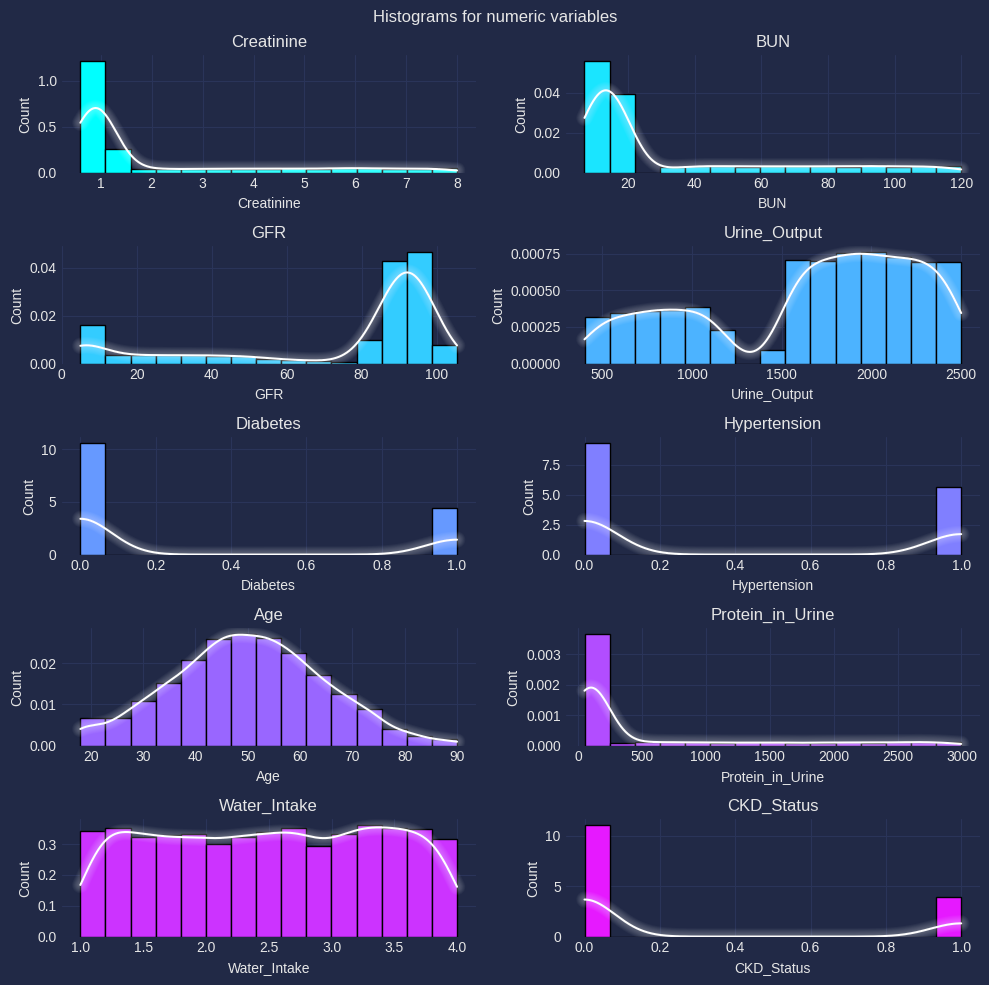

In [11]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(10,10))
fig.suptitle('Histograms for numeric variables')

for idx, col in enumerate(numeric_cols):
    axes = ax[idx // 2, idx % 2]
    kde = gaussian_kde(col)
    x_kde = np.linspace(col.min(), col.max(), len(col))
    axes.set_title(col.name)
    axes.set_xlabel(col.name)
    axes.set_ylabel('Count')
    axes.hist(col, bins=15, edgecolor='black', density=True, color=colors[idx])
    axes.plot(x_kde, kde(x_kde), color='white')
    mplcyberpunk.make_lines_glow(ax=axes)
    plt.tight_layout()

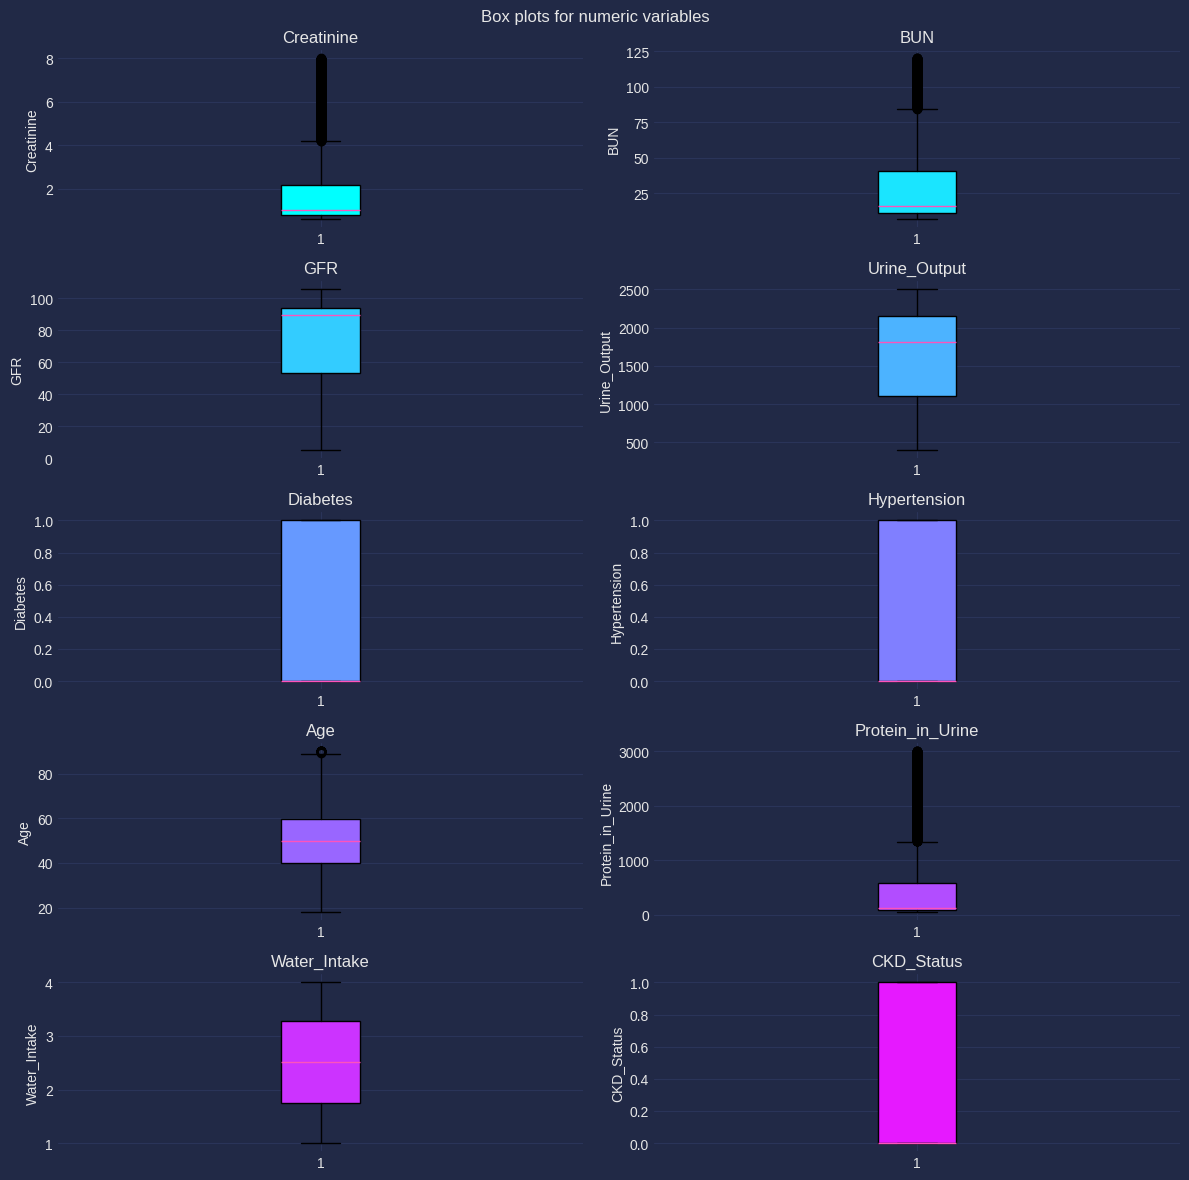

In [12]:
fig, ax = plt.subplots(nrows=5, ncols=2,  figsize=(12,12))
fig.suptitle('Box plots for numeric variables')

for idx, col in enumerate(numeric_cols):
    axes = ax[idx // 2, idx % 2]
    axes.set_title(col.name)
    axes.set_ylabel(col.name)
    bplot = axes.boxplot(col, patch_artist=True)
    bplot['boxes'][0].set_facecolor(colors[idx])
    plt.tight_layout()

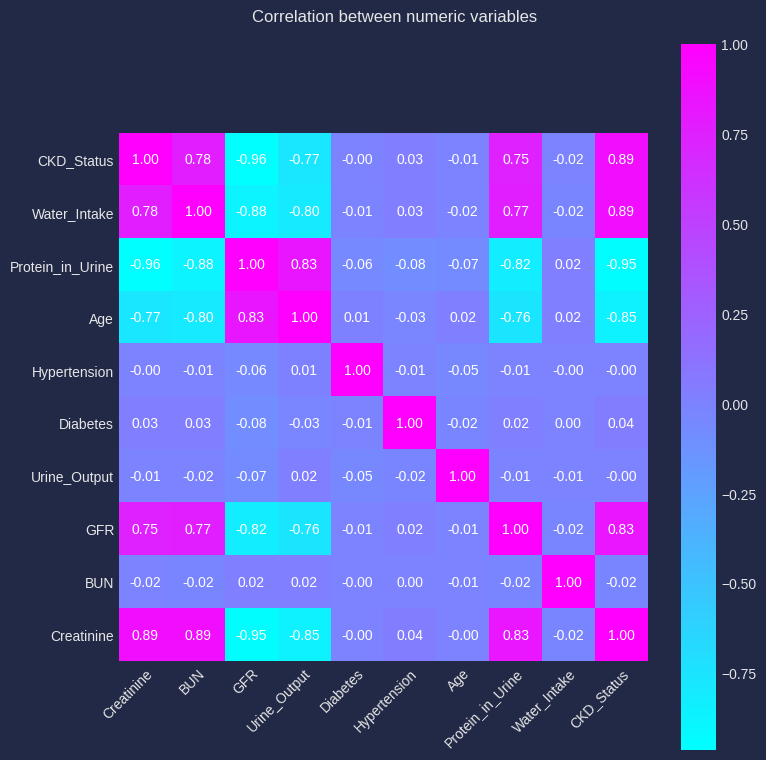

In [13]:
corr = numeric_cols.corr()
xticks = corr.columns
yticks = [xticks[i] for i in range(len(xticks)-1, -1, -1)]

fig, ax = plt.subplots(figsize=(8,8))
fig.suptitle('Correlation between numeric variables')
im = ax.imshow(corr, cmap=cool_cmap)
cbar = ax.figure.colorbar(im, ax=ax)
ax.grid(visible=False)
ax.set_xticks(range(len(xticks)), labels=xticks, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(yticks)), labels=yticks)

for i in range(len(xticks)):
    for j in range(len(yticks)):
        text = ax.text(j, i, "{:.2f}".format(corr[i, j]), ha="center", va="center", color="w")

fig.tight_layout()

#### Dataset creation

In [14]:
train_size = int(len(df) * 0.8)
test_size = int(len(df) * 0.9)

col_to_stype = {
    "Creatinine" : torch_frame.numerical,
    "BUN" : torch_frame.numerical,
    "GFR" : torch_frame.numerical,
    "Urine_Output" : torch_frame.numerical,
    "Diabetes" : torch_frame.categorical,
    "Hypertension" : torch_frame.categorical,
    "Age" : torch_frame.numerical,
    "Protein_in_Urine" : torch_frame.numerical,
    "Water_Intake" : torch_frame.numerical,
    "Medication" : torch_frame.categorical,
    "CKD_Status" : torch_frame.categorical
}

dataset = Dataset(df.to_pandas(), col_to_stype=col_to_stype, target_col="CKD_Status")
dataset.materialize()
dataset.shuffle()

train_dataset = dataset[:train_size]
valid_dataset = dataset[train_size:test_size]
test_dataset = dataset[test_size:]

train_dataloader = DataLoader(train_dataset.tensor_frame, batch_size=64)
valid_dataloader = DataLoader(valid_dataset.tensor_frame, batch_size=64)
test_dataloader = DataLoader(test_dataset.tensor_frame, batch_size=64)

#### Model creation

In [15]:
class Transformer(torch.nn.Module):
    def __init__(
        self,
        channels : int,
        out_channels : int,
        num_layers : int,
        num_heads : int,
        col_stats : dict,
        col_names_dict : dict
    ):
        super().__init__()
        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict={
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder()
            },
        )
        self.tab_transformer_convs = torch.nn.ModuleList([
            TabTransformerConv(
                channels=channels,
                num_heads=num_heads,
            ) for _ in range(num_layers)
        ])
        self.decoder = torch.nn.Linear(channels, out_channels)

    def forward(self, inputs):
        x, _ = self.encoder(inputs)
        for tab_transformer_conv in self.tab_transformer_convs:
            x = tab_transformer_conv(x)
        return self.decoder(x.mean(dim=1))

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Transformer(
    channels=32,
    out_channels=train_dataset.num_classes,
    num_layers=2,
    num_heads=8,
    col_stats=train_dataset.col_stats,
    col_names_dict=train_dataset.tensor_frame.col_names_dict,
).to(device)

#### Model information and viewing

In [17]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Transformer                              --
├─StypeWiseFeatureEncoder: 1-1           --
│    └─ModuleDict: 2-1                   --
│    │    └─EmbeddingEncoder: 3-1        288
│    │    └─LinearEncoder: 3-2           448
├─ModuleList: 1-2                        --
│    └─TabTransformerConv: 2-2           --
│    │    └─LayerNorm: 3-3               64
│    │    └─SelfAttention: 3-4           4,224
│    │    └─LayerNorm: 3-5               64
│    │    └─FFN: 3-6                     12,576
│    └─TabTransformerConv: 2-3           --
│    │    └─LayerNorm: 3-7               64
│    │    └─SelfAttention: 3-8           4,224
│    │    └─LayerNorm: 3-9               64
│    │    └─FFN: 3-10                    12,576
├─Linear: 1-3                            66
Total params: 34,658
Trainable params: 34,658
Non-trainable params: 0

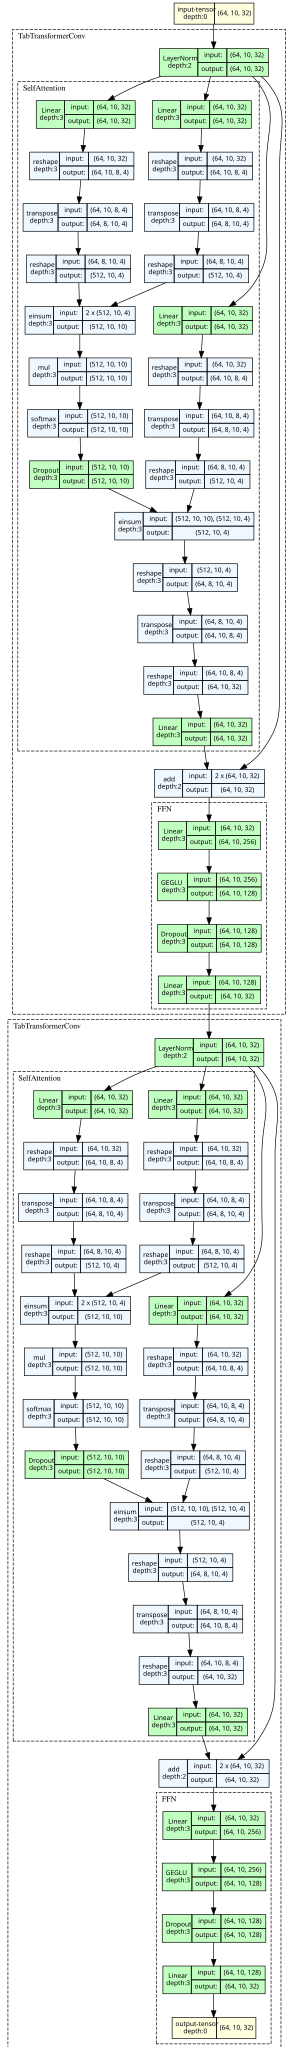

In [18]:
batch = next(iter(train_dataloader))
batch = batch.to(device)
out = model.encoder(batch)[0]

mod = torch.nn.Sequential(*model.tab_transformer_convs)
graph = torchview.draw_graph(mod, input_size=out.shape, expand_nested=True)
graph.visual_graph

#### Training

In [19]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 20

history = {
    'Train Loss' : [],
    'Validation Loss' : [],
    'Train Accuracy' : [],
    'Validation Accuracy' : []
}

for epoch in range(epochs):
    print(f"EPOCH: {epoch+1}")

    train_running_loss = 0.0
    valid_running_loss = 0.0
    train_total_correct = 0.0
    train_total_samples = 0.0
    valid_total_correct = 0.0
    valid_total_samples = 0.0

    model.train()
    for train_batch, train_inputs in enumerate(train_dataloader):
        train_inputs = train_inputs.to(device)
        train_labels = train_inputs.y

        optimizer.zero_grad()
        train_outputs = model(train_inputs)
        train_loss = loss_fn(train_outputs, train_labels)
        train_loss.backward()
        optimizer.step()

        train_preds = train_outputs.argmax(dim=-1)
        train_num_correct = (train_preds == train_labels).sum().item()
        train_running_loss += train_loss.item()
        train_total_correct += train_num_correct
        train_total_samples += train_labels.numel()

    model.eval()
    with torch.no_grad():
        for valid_batch, valid_inputs in enumerate(valid_dataloader):
            valid_inputs = valid_inputs.to(device)
            valid_labels = valid_inputs.y

            valid_outputs = model(valid_inputs)
            valid_loss = loss_fn(valid_outputs, valid_labels)

            valid_preds = valid_outputs.argmax(dim=-1)
            valid_num_correct = (valid_preds == valid_labels).sum().item()
            valid_running_loss += valid_loss.item()
            valid_total_correct += valid_num_correct
            valid_total_samples += valid_labels.numel()
        
    train_avg_loss = train_running_loss / len(train_dataloader)
    train_avg_acc = train_total_correct / train_total_samples
    valid_avg_loss = valid_running_loss / len(valid_dataloader)
    valid_avg_acc = valid_total_correct / valid_total_samples

    history['Train Loss'].append(train_avg_loss)
    history['Validation Loss'].append(valid_avg_loss)
    history['Train Accuracy'].append(train_avg_acc)
    history['Validation Accuracy'].append(valid_avg_acc)
    
    print(f"LOSS: TRAIN: {train_avg_loss:.4f}, VALID: {valid_avg_loss:.4f}")
    print(f"ACC: TRAIN: {train_avg_acc:.4f}%, VALID: {valid_avg_acc:.4f}%")
    print("-"*35)

EPOCH: 1
LOSS: TRAIN: 0.1177, VALID: 0.0097
ACC: TRAIN: 0.9450%, VALID: 0.9960%
-----------------------------------
EPOCH: 2
LOSS: TRAIN: 0.0062, VALID: 0.0063
ACC: TRAIN: 0.9985%, VALID: 0.9980%
-----------------------------------
EPOCH: 3
LOSS: TRAIN: 0.0092, VALID: 0.0113
ACC: TRAIN: 0.9962%, VALID: 0.9980%
-----------------------------------
EPOCH: 4
LOSS: TRAIN: 0.0059, VALID: 0.0149
ACC: TRAIN: 0.9982%, VALID: 0.9920%
-----------------------------------
EPOCH: 5
LOSS: TRAIN: 0.0059, VALID: 0.0086
ACC: TRAIN: 0.9975%, VALID: 0.9960%
-----------------------------------
EPOCH: 6
LOSS: TRAIN: 0.0082, VALID: 0.0155
ACC: TRAIN: 0.9960%, VALID: 0.9940%
-----------------------------------
EPOCH: 7
LOSS: TRAIN: 0.0040, VALID: 0.0174
ACC: TRAIN: 0.9992%, VALID: 0.9900%
-----------------------------------
EPOCH: 8
LOSS: TRAIN: 0.0018, VALID: 0.0161
ACC: TRAIN: 0.9992%, VALID: 0.9940%
-----------------------------------
EPOCH: 9
LOSS: TRAIN: 0.0006, VALID: 0.0023
ACC: TRAIN: 0.9998%, VALID: 

#### Metrics

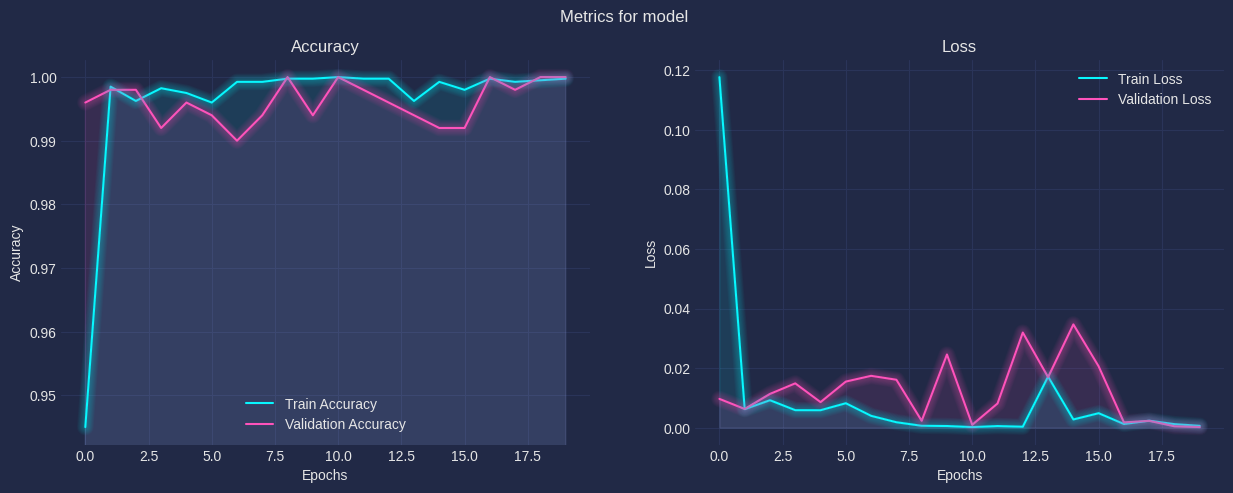

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle('Metrics for model')

def plot_metrics(hist: dict, metric: str, axes: Any) -> None:
    axes.set_title(metric)
    axes.set_xlabel('Epochs')
    axes.set_ylabel(metric)
    axes.plot(hist['Train ' + metric], label='Train ' + metric)
    axes.plot(hist['Validation ' + metric], label='Validation ' + metric)
    axes.legend()
    mplcyberpunk.make_lines_glow(ax=axes)
    mplcyberpunk.add_underglow(ax=axes)

plot_metrics(history, 'Accuracy', ax[0])
plot_metrics(history, 'Loss', ax[1])

In [21]:
def inference(model: Transformer, dataloader: DataLoader, device: str) -> tuple[list, list]:
    preds = []
    labels = []
    
    model.eval()
    with torch.no_grad():
        for _, inputs in enumerate(dataloader):
            inputs = inputs.to(device)
            labels.append(inputs.y.tolist())
            raw_output = model(inputs)
            pred = raw_output.argmax(dim=-1)
            preds.append(pred.tolist())

    return sum(preds, []), sum(labels, [])

In [22]:
test_preds, test_labels = inference(model, test_dataloader, device)

print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       1.00      1.00      1.00       144

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



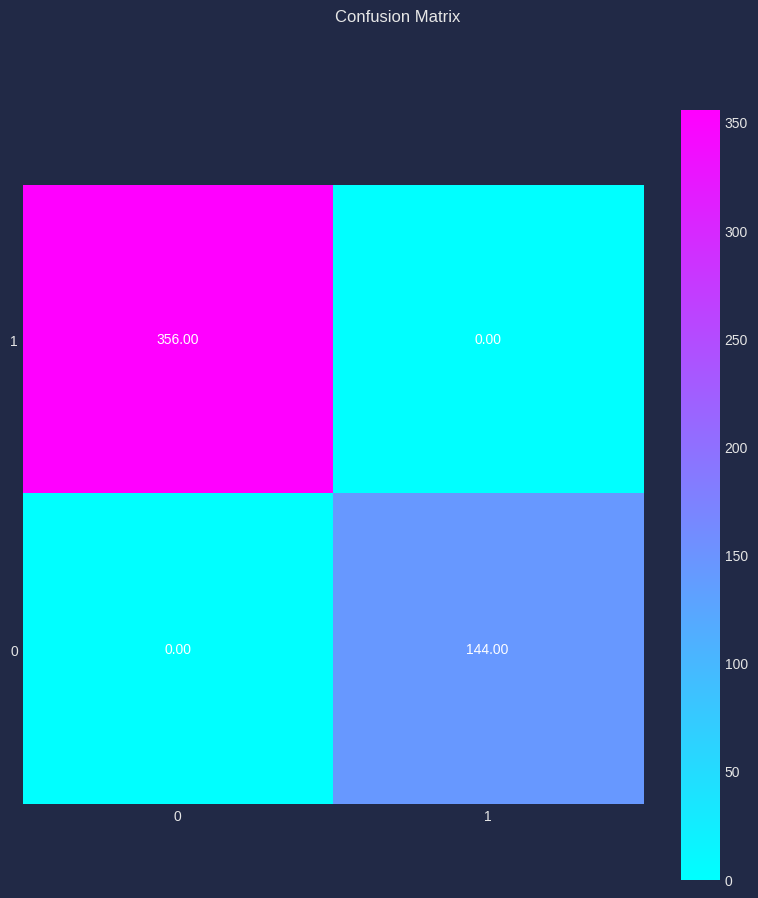

In [23]:
cm = confusion_matrix(test_labels, test_preds)
xticks = [0, 1]
yticks = [1, 0]

fig, ax = plt.subplots(figsize=(10,10))
fig.suptitle('Confusion Matrix')
im = ax.imshow(cm, cmap=cool_cmap)
cbar = ax.figure.colorbar(im, ax=ax)
ax.grid(visible=False)
ax.set_xticks(range(len(xticks)), labels=xticks)
ax.set_yticks(range(len(yticks)), labels=yticks)

for i in range(len(xticks)):
    for j in range(len(yticks)):
        text = ax.text(j, i, "{:.2f}".format(cm[i, j]), ha="center", va="center", color="w")

#### Citations

- PyTorch Frame: A Modular Framework for Multi-Modal Tabular Learning, Hu, Weihua et al., arXiv preprint arXiv:2404.00776, 2024